<center> <h1> Customer profiling for treadmill products provided by a fitness company </h1> </center>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import math

In [3]:
from collections import namedtuple

In [4]:
%matplotlib inline

In [5]:
pd.set_option('display.max_colwidth', 2000)
pd.set_option('display.max_rows', 100)

In [6]:
df = pd.read_csv("fitness_treadmill.csv")

In [7]:
df.columns

Index(['Product', 'Age', 'Gender', 'Education', 'MaritalStatus', 'Usage',
       'Fitness', 'Income', 'Miles'],
      dtype='str')

In [8]:
df.rename(
    columns={
        "Product": "product",
        "Age": "age",
        "Gender": "gender",
        "Education": "education",
        "MaritalStatus": "marital_status",
        "Usage": "usage",
        "Fitness": "fitness",
        "Income": "income",
        "Miles": "miles"
    },
    inplace=True
)

In [9]:
df.columns

Index(['product', 'age', 'gender', 'education', 'marital_status', 'usage',
       'fitness', 'income', 'miles'],
      dtype='str')

## Data Dictionary

**product:** KP281, KP481, or KP781 <br>
**age:** In years<br>
**gender:** Male/Female<br>
**education:** In years<br>
**marital_status:** 	Single or partnered<br>
**usage:** The average number of times the customer plans to use the treadmill each week.<br>
**fitness:** Self-rated fitness on a 1-to-5 scale, where 1 is the poor shape and 5 is the excellent shape. <br>
**income:** 	Annual income (in $) <br>
**miles:** The average number of miles the customer expects to walk/run each week <br>

## Basic EDA

In [10]:
df.head()

,product,age,gender,education,marital_status,usage,fitness,income,miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [11]:
df.shape

(180, 9)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   product         180 non-null    str  
 1   age             180 non-null    int64
 2   gender          180 non-null    str  
 3   education       180 non-null    int64
 4   marital_status  180 non-null    str  
 5   usage           180 non-null    int64
 6   fitness         180 non-null    int64
 7   income          180 non-null    int64
 8   miles           180 non-null    int64
dtypes: int64(6), str(3)
memory usage: 12.8 KB


In [13]:
df.describe(include='all')

,product,age,gender,education,marital_status,usage,fitness,income,miles
count,180,180.000000,180,180.000000,180,180.000000,180.000000,180.000000,180.000000
unique,3,NaN,2,NaN,2,NaN,NaN,NaN,NaN
top,KP281,NaN,Male,NaN,Partnered,NaN,NaN,NaN,NaN
freq,80,NaN,104,NaN,107,NaN,NaN,NaN,NaN
mean,NaN,28.788889,NaN,15.572222,NaN,3.455556,3.311111,53719.577778,103.194444
std,NaN,6.943498,NaN,1.617055,NaN,1.084797,0.958869,16506.684226,51.863605
min,NaN,18.000000,NaN,12.000000,NaN,2.000000,1.000000,29562.000000,21.000000
25%,NaN,24.000000,NaN,14.000000,NaN,3.000000,3.000000,44058.750000,66.000000
50%,NaN,26.000000,NaN,16.000000,NaN,3.000000,3.000000,50596.500000,94.000000
75%,NaN,33.000000,NaN,16.000000,NaN,4.000000,4.000000,58668.000000,114.750000


In [14]:
df['product'].value_counts()

product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64

In [15]:
df['age'].value_counts()

age
25    25
23    18
24    12
26    12
28     9
33     8
35     8
21     7
22     7
27     7
30     7
38     7
29     6
31     6
34     6
20     5
40     5
19     4
32     4
37     2
47     2
45     2
48     2
18     1
36     1
39     1
41     1
43     1
44     1
46     1
50     1
42     1
Name: count, dtype: int64

In [16]:
df['gender'].value_counts()

gender
Male      104
Female     76
Name: count, dtype: int64

In [17]:
df['education'].value_counts()

education
16    85
14    55
18    23
15     5
13     5
12     3
21     3
20     1
Name: count, dtype: int64

In [18]:
df['marital_status'].value_counts()

marital_status
Partnered    107
Single        73
Name: count, dtype: int64

In [19]:
df['usage'].value_counts()

usage
3    69
4    52
2    33
5    17
6     7
7     2
Name: count, dtype: int64

In [20]:
df['fitness'].value_counts()

fitness
3    97
5    31
2    26
4    24
1     2
Name: count, dtype: int64

In [21]:
df['income'].value_counts().head(10)

income
45480    14
52302     9
46617     8
53439     8
54576     8
51165     7
50028     7
40932     6
32973     5
35247     5
Name: count, dtype: int64

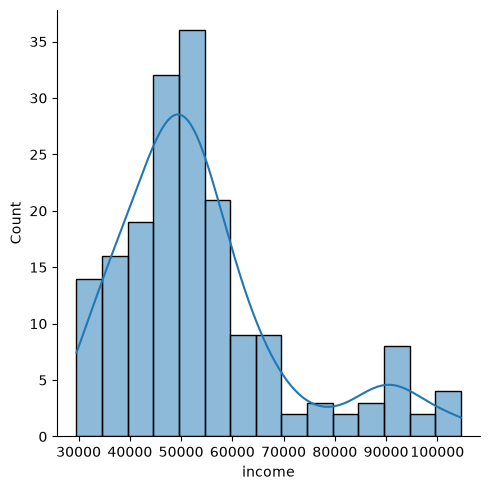

In [22]:
sns.displot(df['income'], kde=True)

In [23]:
df['miles'].value_counts().head(10)

miles
85     27
95     12
75     10
66     10
47      9
106     9
94      8
113     8
53      7
100     7
Name: count, dtype: int64

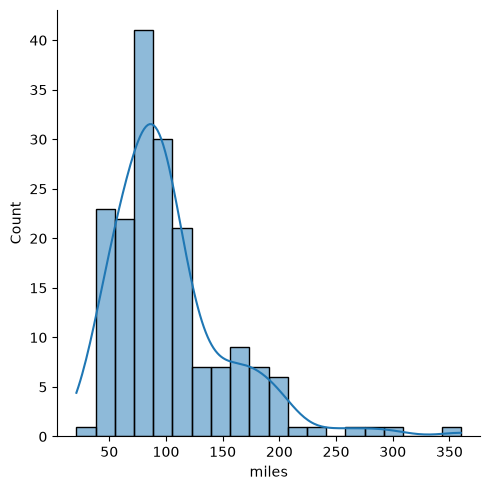

In [24]:
sns.displot(df['miles'], kde=True)

### Check for null values

In [25]:
for col in df.columns:
    null_count = len(df.loc[df[col].isna()])
    percentage_null = round(null_count / len(df) * 100, 2)
    print(f"For col {col}, null_count: {null_count}, percentage_null: {percentage_null}")

For col product, null_count: 0, percentage_null: 0.0
For col age, null_count: 0, percentage_null: 0.0
For col gender, null_count: 0, percentage_null: 0.0
For col education, null_count: 0, percentage_null: 0.0
For col marital_status, null_count: 0, percentage_null: 0.0
For col usage, null_count: 0, percentage_null: 0.0
For col fitness, null_count: 0, percentage_null: 0.0
For col income, null_count: 0, percentage_null: 0.0
For col miles, null_count: 0, percentage_null: 0.0


No null values present in our dataset.

## Fix Column/Feature Data Types

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   product         180 non-null    str  
 1   age             180 non-null    int64
 2   gender          180 non-null    str  
 3   education       180 non-null    int64
 4   marital_status  180 non-null    str  
 5   usage           180 non-null    int64
 6   fitness         180 non-null    int64
 7   income          180 non-null    int64
 8   miles           180 non-null    int64
dtypes: int64(6), str(3)
memory usage: 12.8 KB


These columns can be converted to categorical:
`product`, `gender`, `marital_status`

In [27]:
df[['product', 'gender', 'marital_status']] = df[['product', 'gender', 'marital_status']].astype('category')

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   product         180 non-null    category
 1   age             180 non-null    int64   
 2   gender          180 non-null    category
 3   education       180 non-null    int64   
 4   marital_status  180 non-null    category
 5   usage           180 non-null    int64   
 6   fitness         180 non-null    int64   
 7   income          180 non-null    int64   
 8   miles           180 non-null    int64   
dtypes: category(3), int64(6)
memory usage: 9.1 KB


## Check for Outliers

In [29]:
numeric_cols = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col])]
numeric_cols

['age', 'education', 'usage', 'fitness', 'income', 'miles']

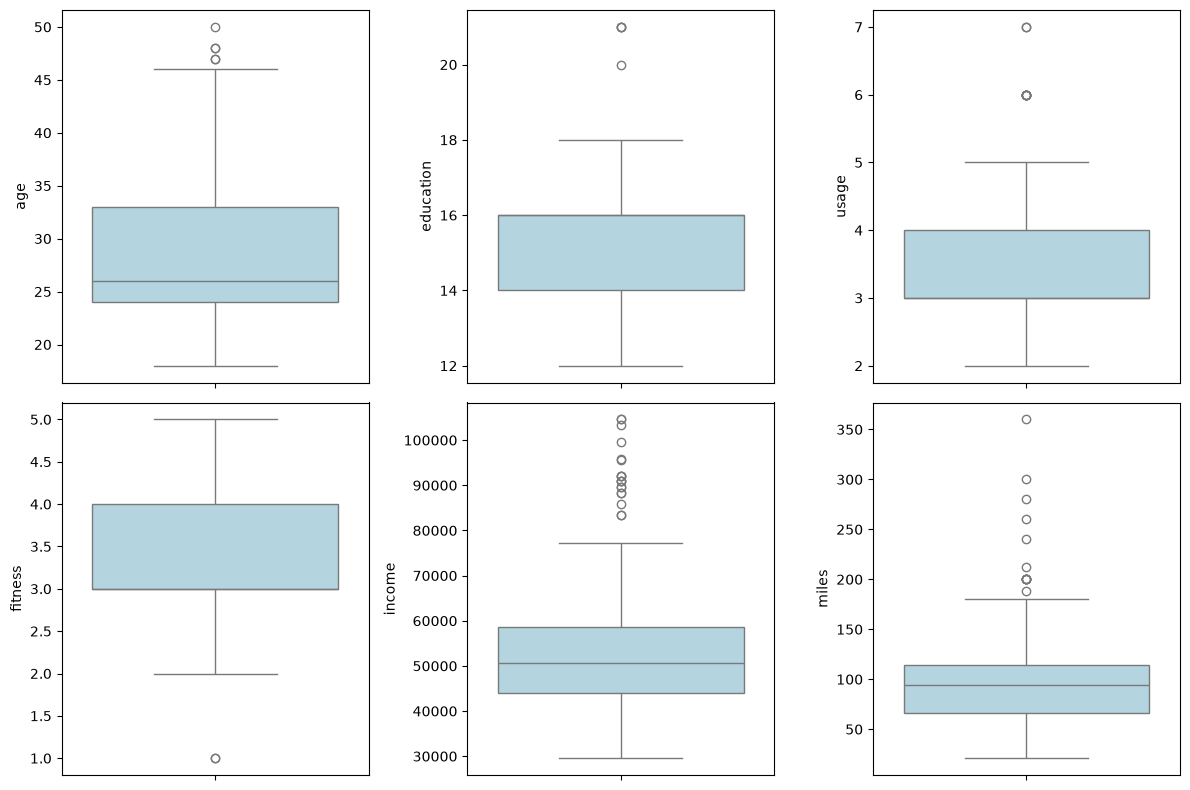

In [30]:
num_columns = len(numeric_cols)

# Set up the subplot grid
ncols = 3 
nrows = int(np.ceil(num_columns / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), sharey=False)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot each boxplot on its respective subplot
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
    #axes[i].set_title(f'{col}')
    #axes[i].set_xlabel(col)
    #axes[i].set_ylabel("Values")

plt.tight_layout()
plt.show()


In [31]:
Bound = namedtuple('Bound', ['lower_bound', 'upper_bound'])
def get_outlier_bounds(dfin, col):
    if not pd.api.types.is_numeric_dtype(dfin[col]):
        raise Exception("Col type is not numeric.")
    Q1 = dfin[col].quantile(0.25)
    Q3 = dfin[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)  
    return Bound(lower_bound, upper_bound)

In [32]:
def get_outlier_df(df, col, bounds: Bound):
    return df.loc[(df[col] < bounds.lower_bound) | (df[col] > bounds.upper_bound)]

### Outliers for  `age`

In [33]:
age_bounds = get_outlier_bounds(df, 'age')
age_bounds

Bound(lower_bound=np.float64(10.5), upper_bound=np.float64(46.5))

In [34]:
age_outliers_df = get_outlier_df(df, 'age', age_bounds)

In [35]:
age_outliers_df.shape

(5, 9)

In [36]:
age_outliers_df

,product,age,gender,education,marital_status,usage,fitness,income,miles
78,KP281,47,Male,16,Partnered,4,3,56850,94
79,KP281,50,Female,16,Partnered,3,3,64809,66
139,KP481,48,Male,16,Partnered,2,3,57987,64
178,KP781,47,Male,18,Partnered,4,5,104581,120
179,KP781,48,Male,18,Partnered,4,5,95508,180


No need to treat/remove these outliers, these are acceptable values.

### Outliers for `education`

In [37]:
education_bounds = get_outlier_bounds(df, 'education')
education_bounds

Bound(lower_bound=np.float64(11.0), upper_bound=np.float64(19.0))

In [38]:
education_outliers_df = get_outlier_df(df, 'education', education_bounds)
education_outliers_df.shape

(4, 9)

In [39]:
education_outliers_df

,product,age,gender,education,marital_status,usage,fitness,income,miles
156,KP781,25,Male,20,Partnered,4,5,74701,170
157,KP781,26,Female,21,Single,4,3,69721,100
161,KP781,27,Male,21,Partnered,4,4,90886,100
175,KP781,40,Male,21,Single,6,5,83416,200


No need to treat/remove these outliers, these are acceptable values.

### Outliers for `usage`

In [40]:
usage_bounds = get_outlier_bounds(df, 'usage')
usage_bounds

Bound(lower_bound=np.float64(1.5), upper_bound=np.float64(5.5))

In [41]:
usage_outliers_df = get_outlier_df(df, 'usage', usage_bounds)
usage_outliers_df.shape

(9, 9)

In [42]:
usage_outliers_df

,product,age,gender,education,marital_status,usage,fitness,income,miles
154,KP781,25,Male,18,Partnered,6,4,70966,180
155,KP781,25,Male,18,Partnered,6,5,75946,240
162,KP781,28,Female,18,Partnered,6,5,92131,180
163,KP781,28,Male,18,Partnered,7,5,77191,180
164,KP781,28,Male,18,Single,6,5,88396,150
166,KP781,29,Male,14,Partnered,7,5,85906,300
167,KP781,30,Female,16,Partnered,6,5,90886,280
170,KP781,31,Male,16,Partnered,6,5,89641,260
175,KP781,40,Male,21,Single,6,5,83416,200


Max usage can be 7, these are acceptable values.

### Outliers for `fitness`

In [43]:
fitness_bounds = get_outlier_bounds(df, 'fitness')
fitness_bounds

Bound(lower_bound=np.float64(1.5), upper_bound=np.float64(5.5))

In [44]:
fitness_outliers_df = get_outlier_df(df, 'fitness', fitness_bounds)
fitness_outliers_df.shape

(2, 9)

In [45]:
fitness_outliers_df

,product,age,gender,education,marital_status,usage,fitness,income,miles
14,KP281,23,Male,16,Partnered,3,1,38658,47
117,KP481,31,Female,18,Single,2,1,65220,21


Fitness values can range between 1 and 5, so these are acceptable.

### Outliers for `income`

In [46]:
income_bounds = get_outlier_bounds(df, 'income')
income_bounds

Bound(lower_bound=np.float64(22144.875), upper_bound=np.float64(80581.875))

In [47]:
income_outliers_df = get_outlier_df(df, 'income', income_bounds)
income_outliers_df.shape

(19, 9)

In [48]:
income_outliers_df

,product,age,gender,education,marital_status,usage,fitness,income,miles
159,KP781,27,Male,16,Partnered,4,5,83416,160
160,KP781,27,Male,18,Single,4,3,88396,100
161,KP781,27,Male,21,Partnered,4,4,90886,100
162,KP781,28,Female,18,Partnered,6,5,92131,180
164,KP781,28,Male,18,Single,6,5,88396,150
166,KP781,29,Male,14,Partnered,7,5,85906,300
167,KP781,30,Female,16,Partnered,6,5,90886,280
168,KP781,30,Male,18,Partnered,5,4,103336,160
169,KP781,30,Male,18,Partnered,5,5,99601,150
170,KP781,31,Male,16,Partnered,6,5,89641,260


No need to treat/remove these outliers, these are acceptable values.

### Outliers for `miles`

In [49]:
miles_bounds = get_outlier_bounds(df, 'miles')
miles_bounds

Bound(lower_bound=np.float64(-7.125), upper_bound=np.float64(187.875))

In [50]:
miles_outliers_df = get_outlier_df(df, 'miles', miles_bounds)
miles_outliers_df.shape

(13, 9)

In [51]:
miles_outliers_df

,product,age,gender,education,marital_status,usage,fitness,income,miles
23,KP281,24,Female,16,Partnered,5,5,44343,188
84,KP481,21,Female,14,Partnered,5,4,34110,212
142,KP781,22,Male,18,Single,4,5,48556,200
148,KP781,24,Female,16,Single,5,5,52291,200
152,KP781,25,Female,18,Partnered,5,5,61006,200
155,KP781,25,Male,18,Partnered,6,5,75946,240
166,KP781,29,Male,14,Partnered,7,5,85906,300
167,KP781,30,Female,16,Partnered,6,5,90886,280
170,KP781,31,Male,16,Partnered,6,5,89641,260
171,KP781,33,Female,18,Partnered,4,5,95866,200


We could remove the 2 data points where miles 300 and above, but just 2 data-points shouldn't have much effect on analysis.

## Data Analysis

### Analyze - individual features relate to the `product`(KP781, KP481, KP281)

#### `age`

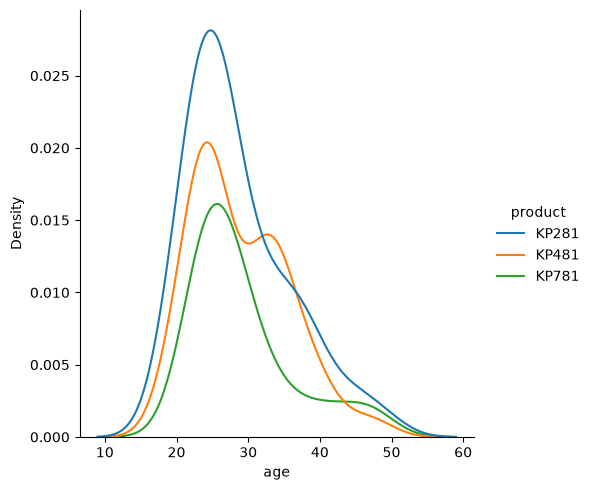

In [52]:
sns.displot(data=df, x='age', hue='product', kind='kde')

In [53]:
def plot_hist(df, product, feature, height=None, aspect=None):
    """
    product: 'KP281' / 'KP481' / 'KP781'
    feature: 'age' / 'education' / 'usage' / 'fitness' / 'income' / 'miles'
    height: height of plot in inches
    aspect: makes width as height*aspect, e.g. for height=5, width = 5*1.5 = 7.5
    """    
    if height and aspect:
        facetgrid = sns.displot(data=df.loc[df['product'] == product], x=feature, height=height, aspect=aspect)
    elif aspect:
        facetgrid = sns.displot(data=df.loc[df['product'] == product], x=feature, aspect=aspect)
    else:
        facetgrid = sns.displot(data=df.loc[df['product'] == product], x=feature)

    # Align xticks to center of each bin
    ax = facetgrid.ax  # Matplotlob axes object
    patches = ax.patches # Each patch corresponds to a bin in the histogram
    bin_centers = [patch.get_x() + (patch.get_width() / 2) for patch in patches]
    ax.set_xticks(bin_centers)

    assert len(patches) > 0, "Got 0 patches/bins"
    bin_width = patches[0].get_width()
    # Annotate each bar with its bin range
    for patch in patches:
        left_edge = patch.get_x()
        right_edge = left_edge + bin_width
        # Create a label for the bin range
        label = f"{left_edge:.1f} - {right_edge:.1f}"
        # Get the height of the bar for placing the text
        height = patch.get_height()
        # Annotate the bar
        ax.text(left_edge + bin_width / 2, height + 0.5, label, ha='center', va='bottom', rotation=90)
    
    plt.show()

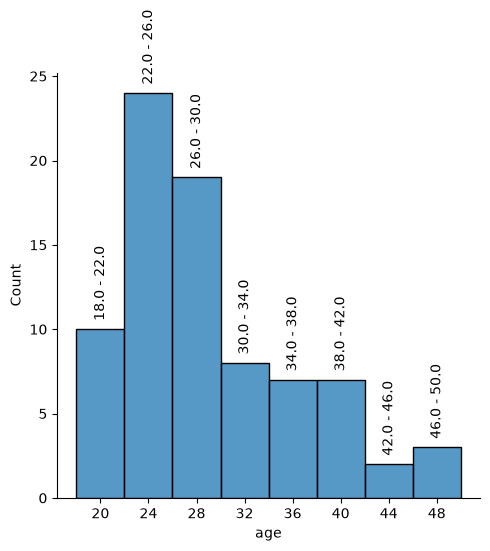

In [54]:
plot_hist(df, product='KP281', feature='age')

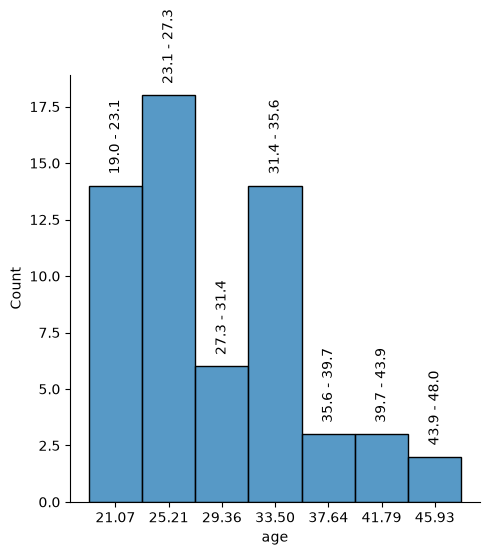

In [55]:
plot_hist(df, product='KP481', feature='age')

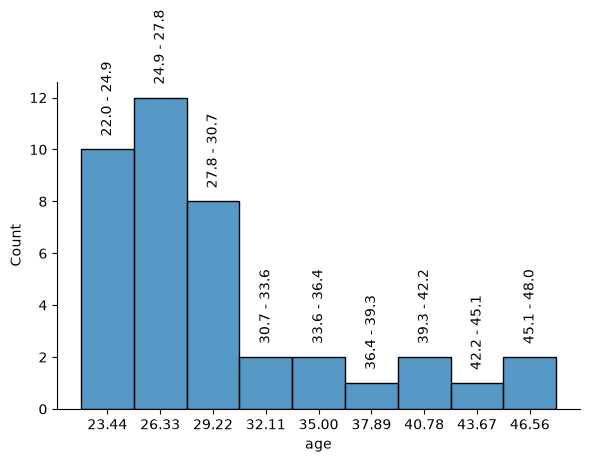

In [56]:
plot_hist(df, product='KP781', feature='age', height=4, aspect=1.5)

#### `education`

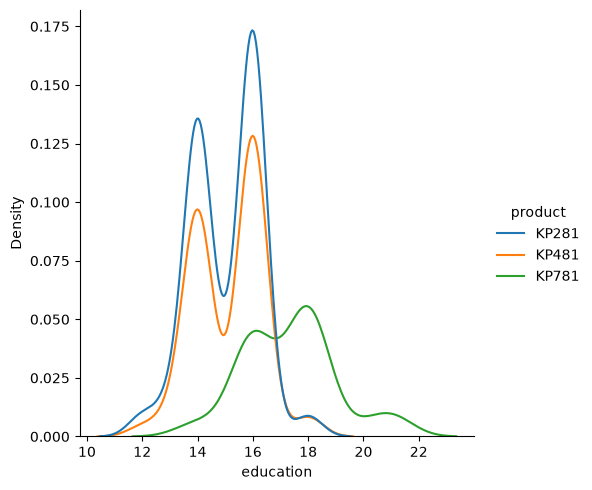

In [57]:
sns.displot(data=df, x='education', hue='product', kind='kde')

In [58]:
def plot_bar(df, feature: str):
    """
    feature: 'education' / 'usage' / 'fitness'
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    facetgrid = sns.barplot(ax=axes[0], data=df.loc[df['product'] == 'KP281', feature].value_counts().reset_index(), x=feature, y='count')
    axes[0].bar_label(facetgrid.containers[0], fmt='%.f', label_type='edge') # , rotation=45)
    axes[0].set_title('KP281')
    
    facetgrid = sns.barplot(ax=axes[1], data=df.loc[df['product'] == 'KP481', feature].value_counts().reset_index(), x=feature, y='count')
    axes[1].bar_label(facetgrid.containers[0], fmt='%.f', label_type='edge')
    axes[1].set_title('KP481')
    
    facetgrid = sns.barplot(ax=axes[2], data=df.loc[df['product'] == 'KP781', feature].value_counts().reset_index(), x=feature, y='count')
    axes[2].bar_label(facetgrid.containers[0], fmt='%.f', label_type='edge')
    axes[2].set_title('KP781')
    
    plt.show()

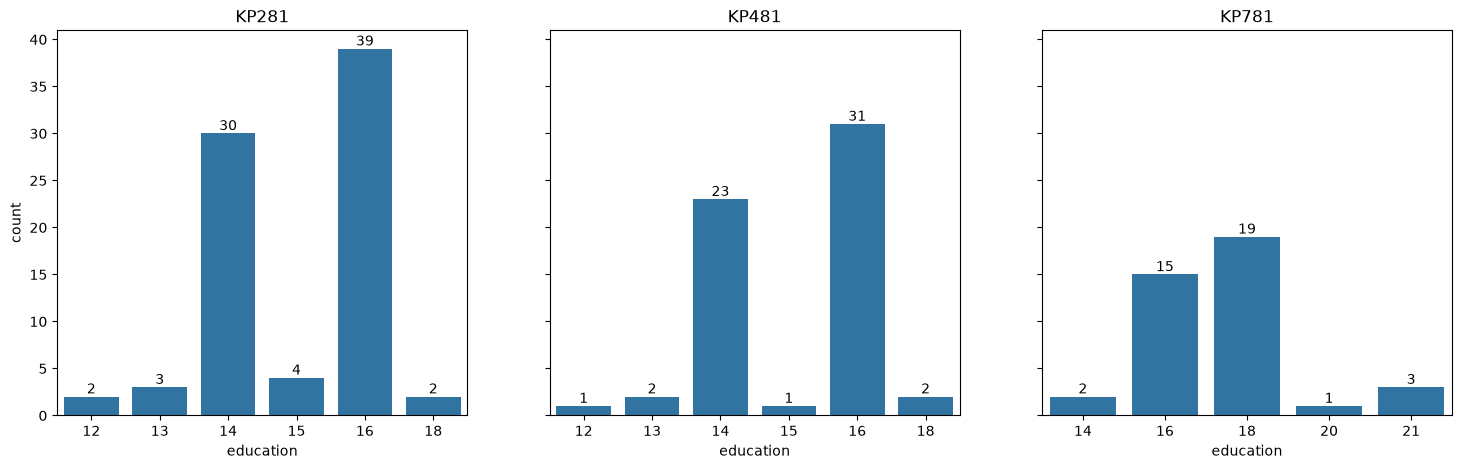

In [59]:
plot_bar(df, 'education')

#### `usage`

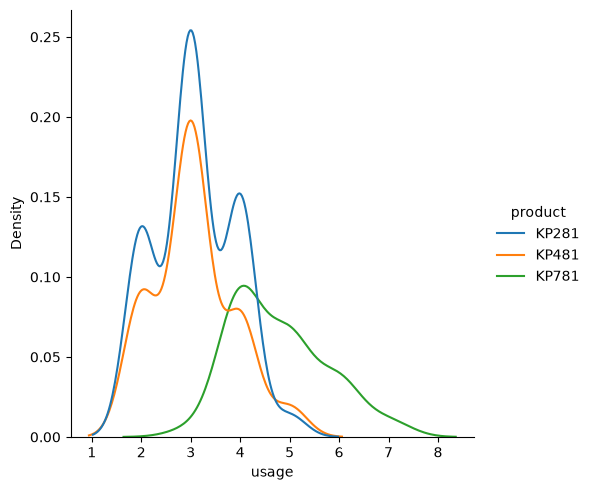

In [60]:
sns.displot(data=df, x='usage', hue='product', kind='kde')

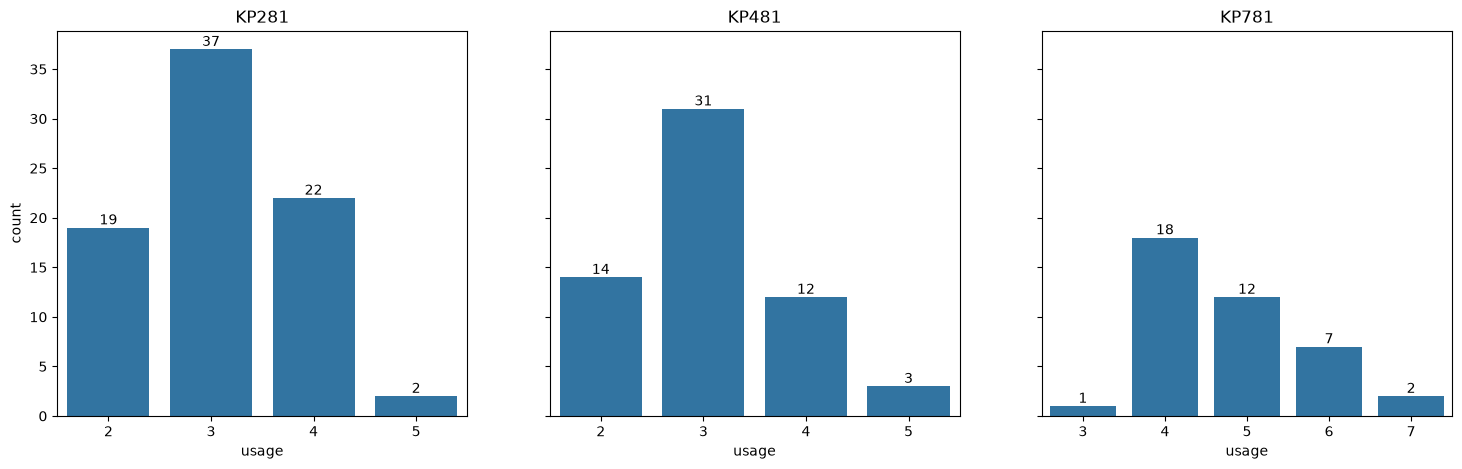

In [61]:
plot_bar(df, 'usage')

#### `fitness`

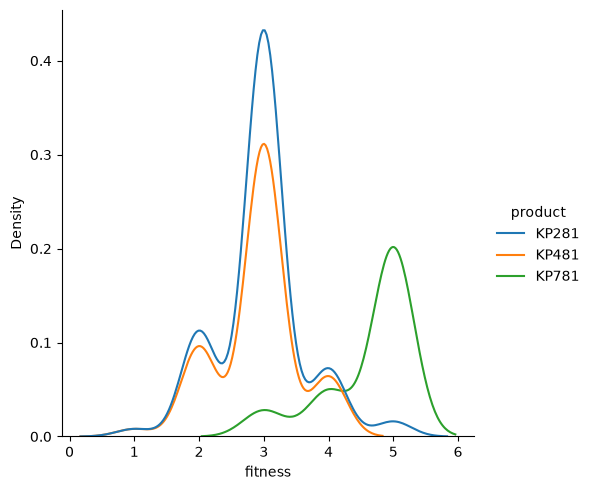

In [62]:
sns.displot(data=df, x='fitness', hue='product', kind='kde')

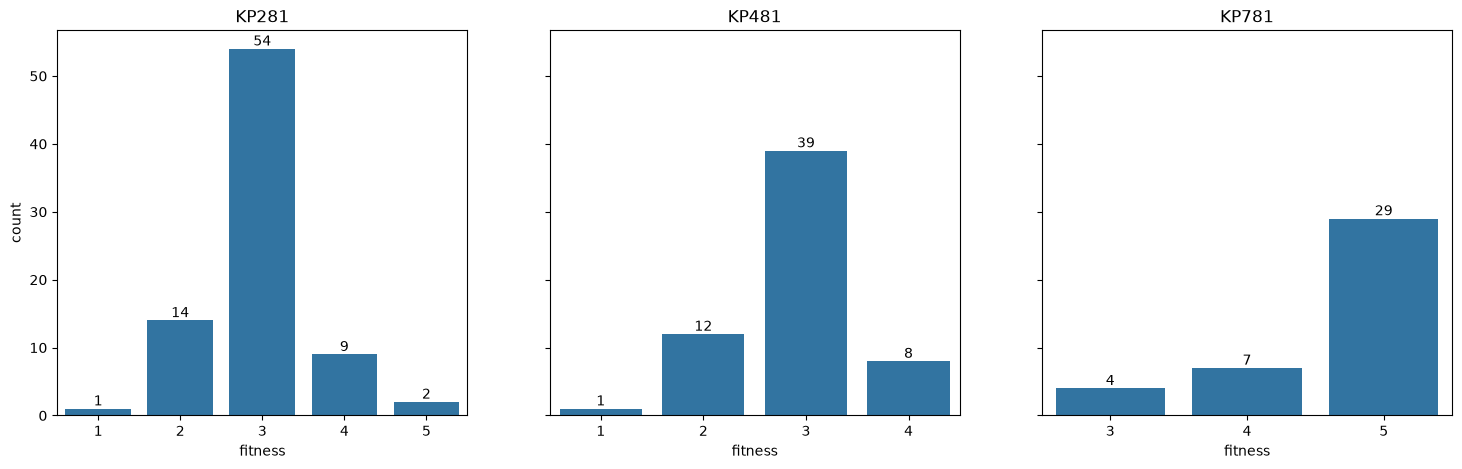

In [63]:
plot_bar(df, 'fitness')

#### `income`

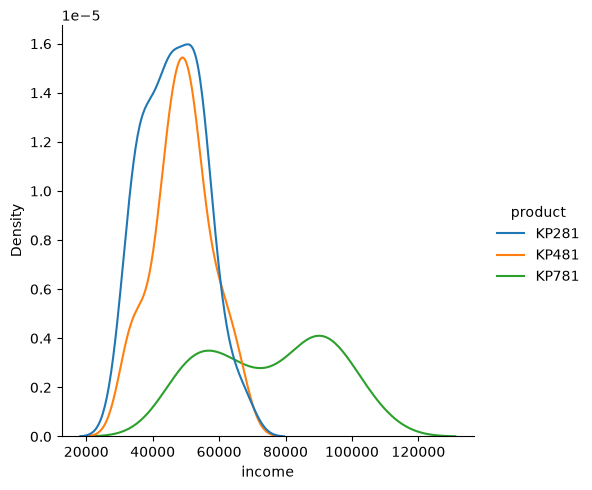

In [64]:
sns.displot(data=df, x='income', hue='product', kind='kde')

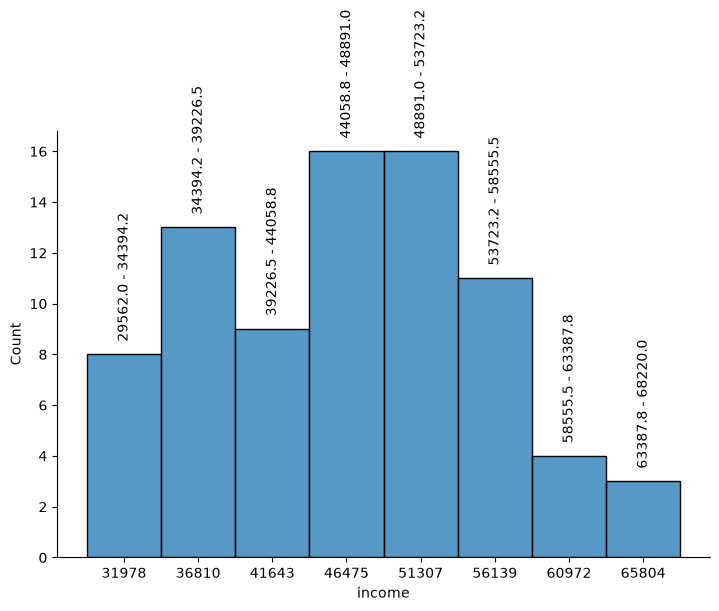

In [65]:
plot_hist(df, product='KP281', feature='income', aspect=1.5)

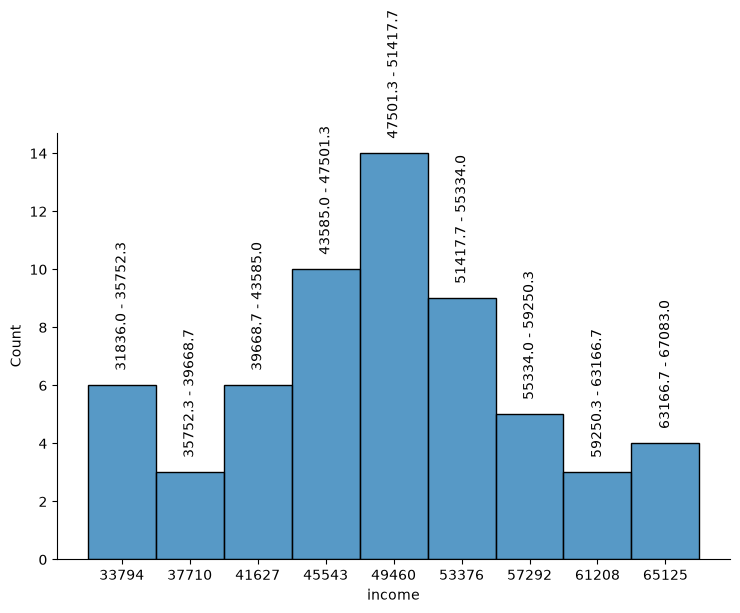

In [66]:
plot_hist(df, product='KP481', feature='income', aspect=1.5)

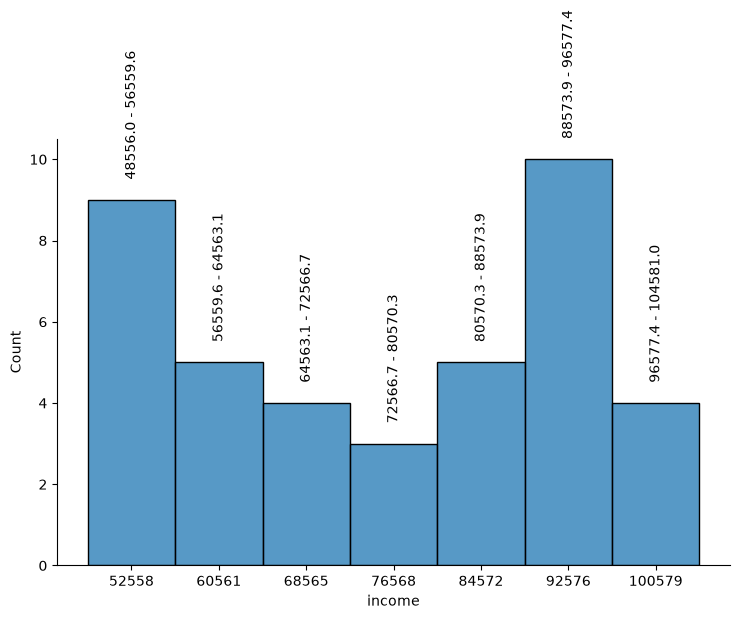

In [67]:
plot_hist(df, product='KP781', feature='income', aspect=1.5)

#### `miles`

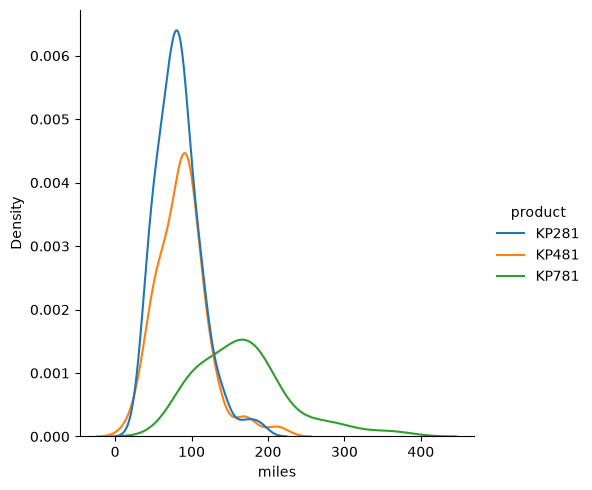

In [68]:
sns.displot(data=df, x='miles', hue='product', kind='kde')

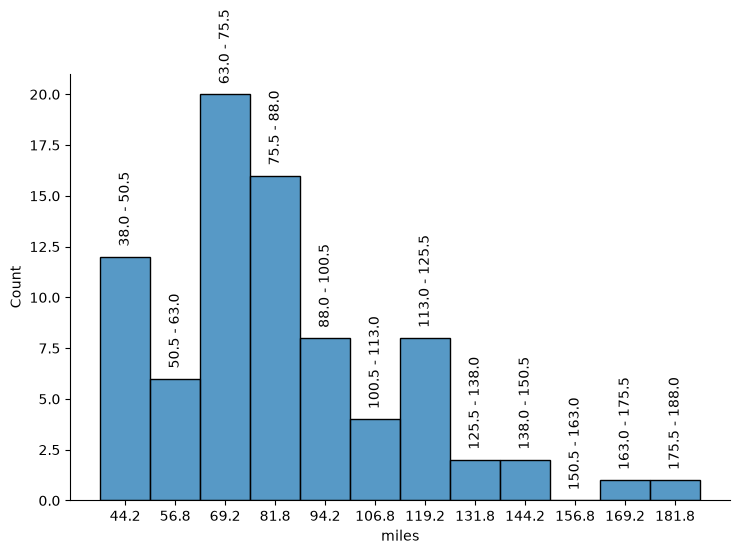

In [69]:
plot_hist(df, product='KP281', feature='miles', aspect=1.5)

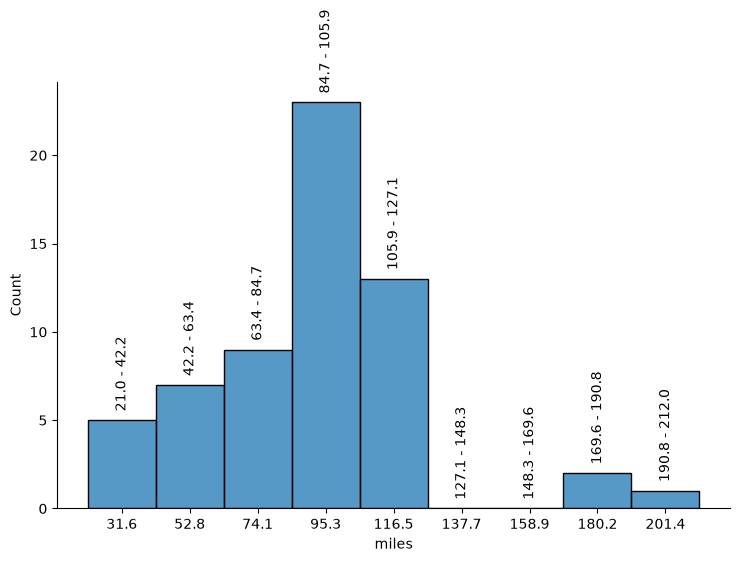

In [70]:
plot_hist(df, product='KP481', feature='miles', aspect=1.5)

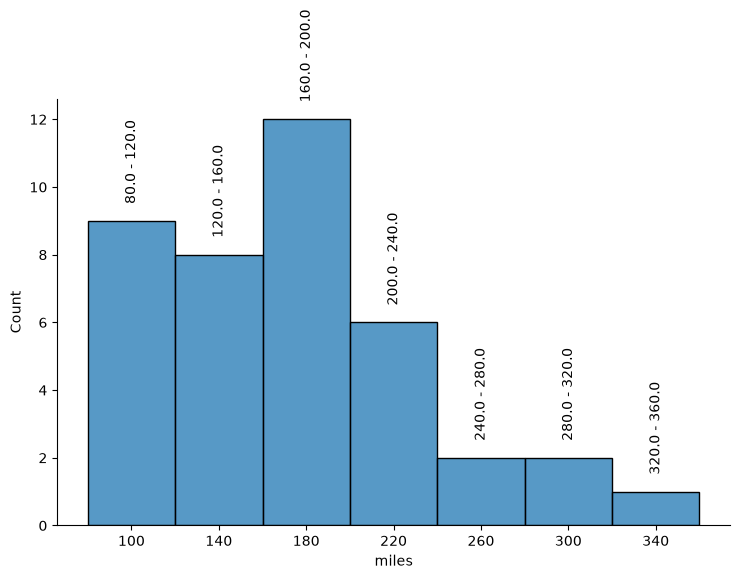

In [71]:
plot_hist(df, product='KP781', feature='miles', aspect=1.5)

#### `gender`

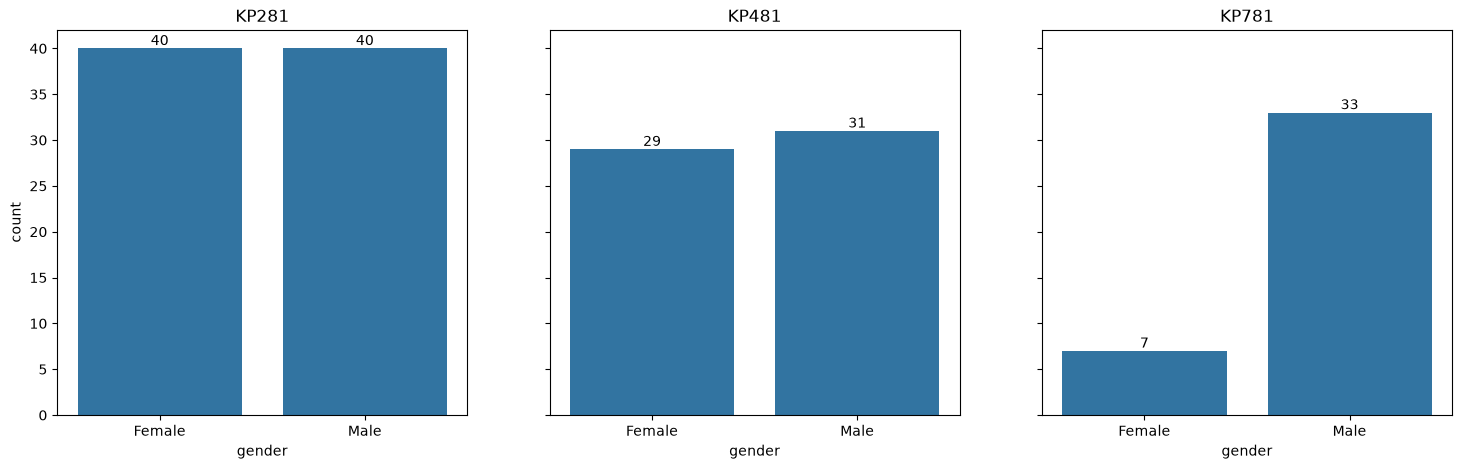

In [72]:
plot_bar(df, 'gender')

#### `marital_status`

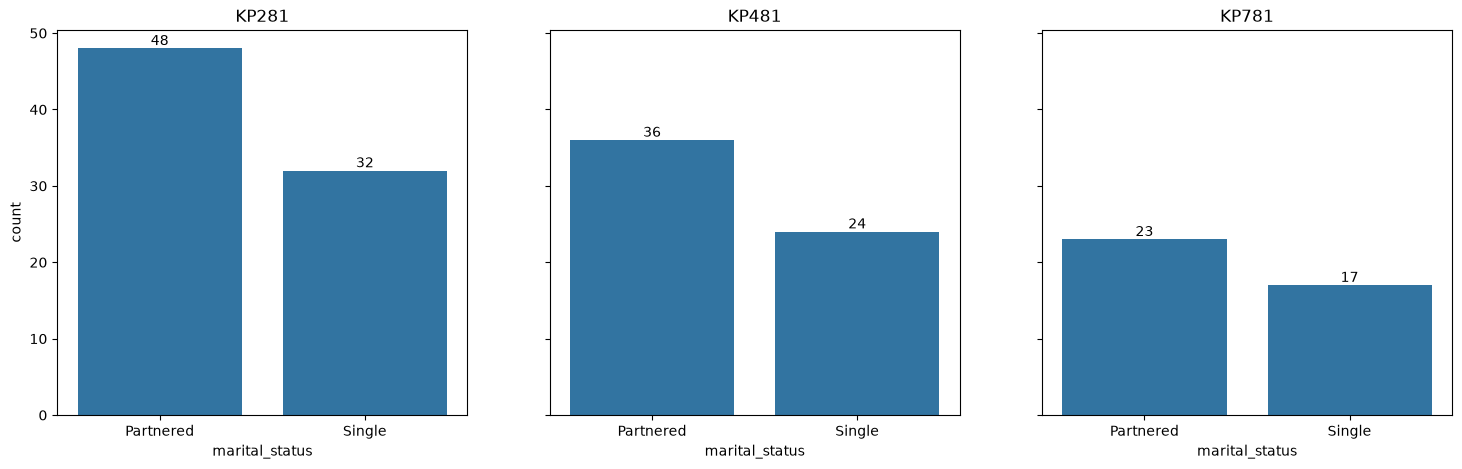

In [73]:
plot_bar(df, 'marital_status')

#### `product`

<Axes: xlabel='count', ylabel='product'>

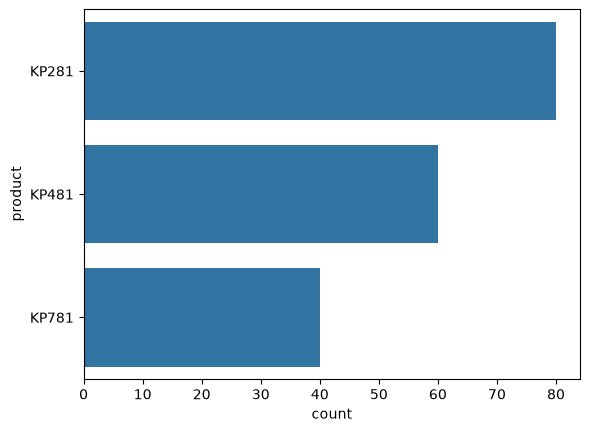

In [74]:
sns.countplot(df['product'])

### Correlation between numeric features

In [75]:
df_num = df.loc[:, ['age', 'education', 'usage', 'fitness', 'income', 'miles']]
df_num.head()

,age,education,usage,fitness,income,miles
0,18,14,3,4,29562,112
1,19,15,2,3,31836,75
2,19,14,4,3,30699,66
3,19,12,3,3,32973,85
4,20,13,4,2,35247,47


<Axes: >

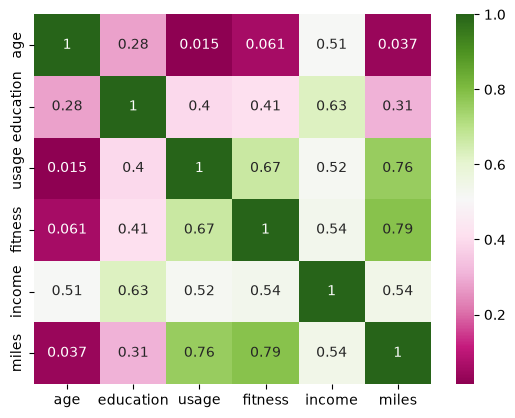

In [76]:
correlation_matrix = df_num.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='PiYG')

There are no negative correlations, don't see negative values on the scale.

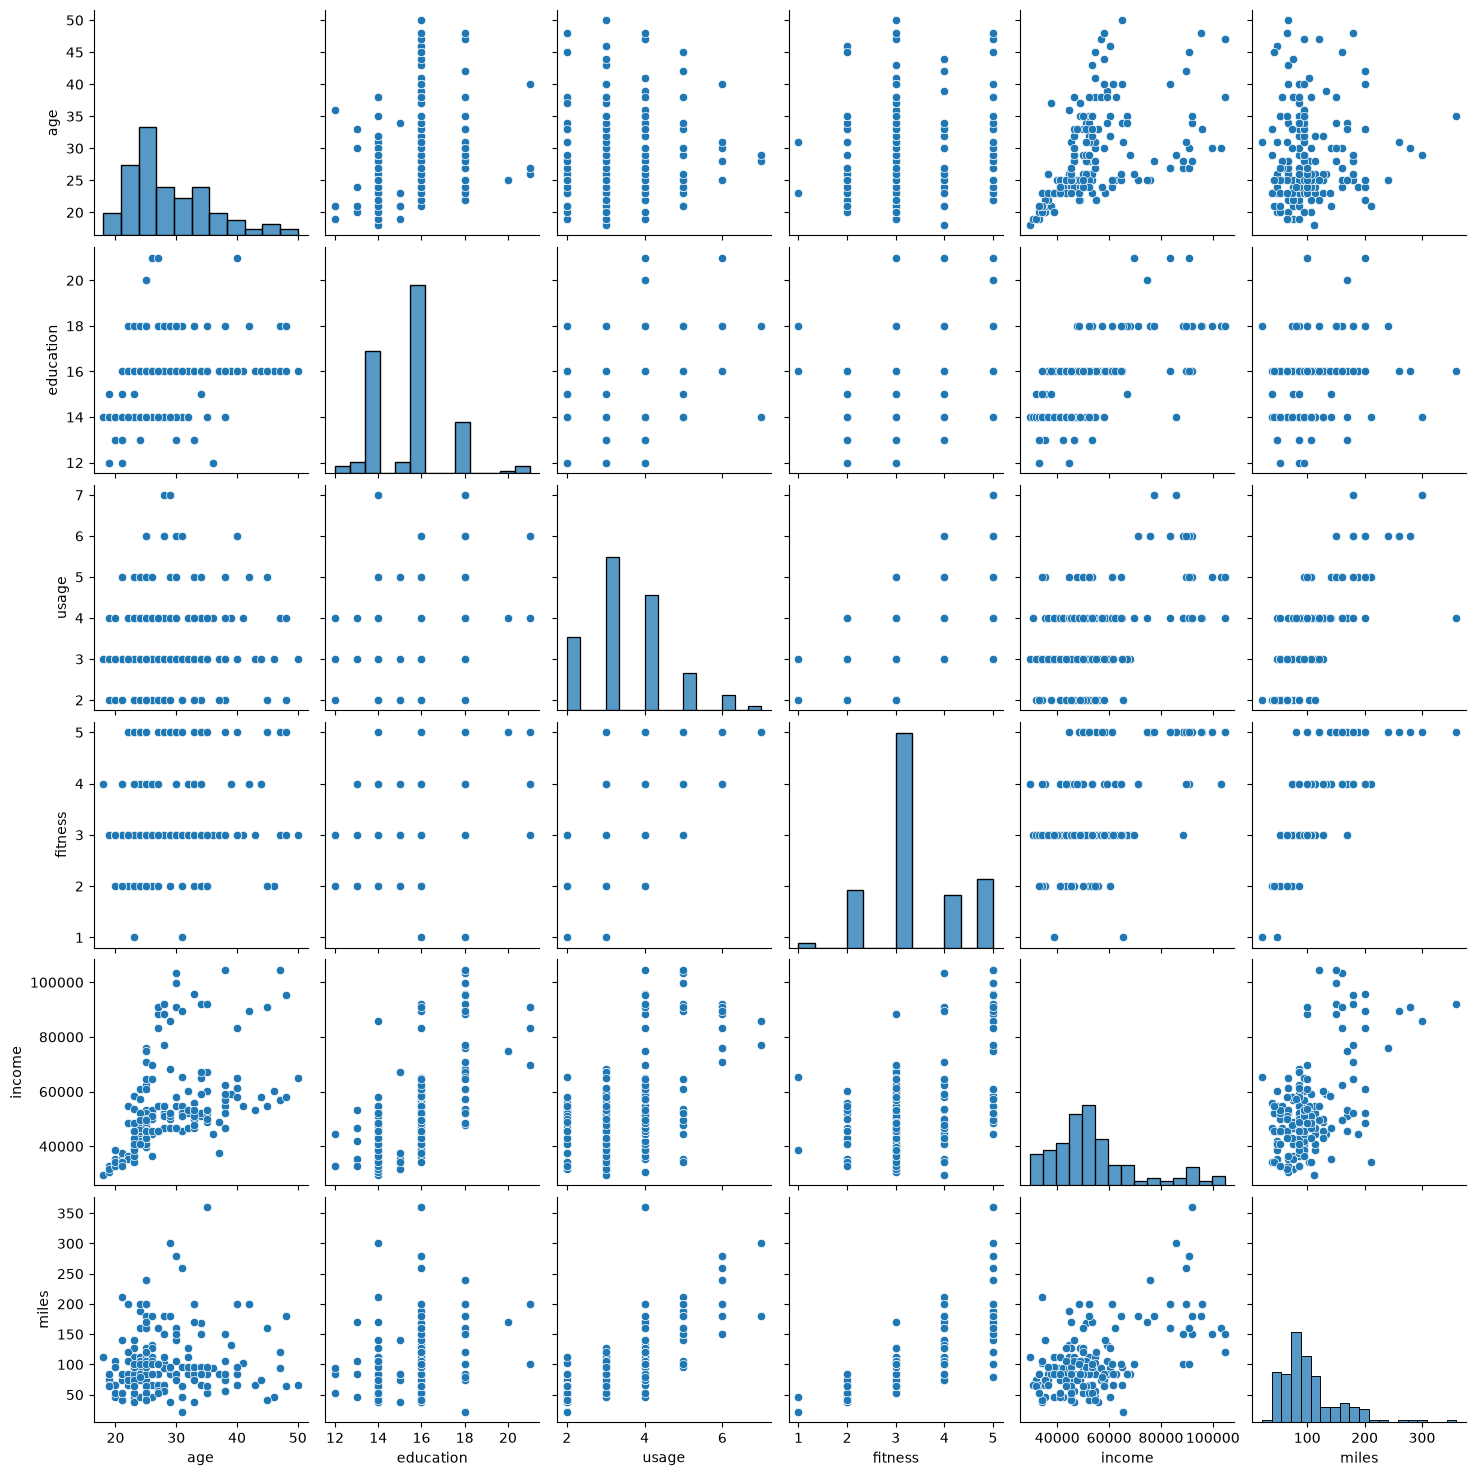

In [77]:
sns.pairplot(df)

### Categegorise numeric features into buckets

In [78]:
df_cat = df.copy()

#### `age`

In [79]:
df_cat['age'].min()

np.int64(18)

In [80]:
df_cat['age'].max()

np.int64(50)

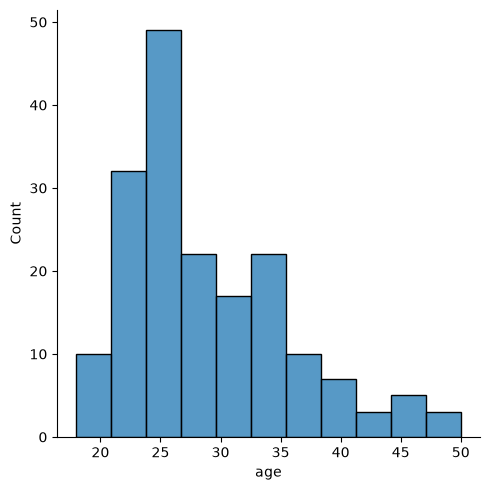

In [81]:
sns.displot(df_cat['age'])

In [82]:
bins = [0, 25, 40, 100]
labels = ['low_age', 'med_age', 'high_age']
df_cat['age_cat'] = pd.cut(df_cat['age'], bins=bins, labels=labels, right=True)
df_cat['age_cat'].value_counts()

age_cat
med_age     89
low_age     79
high_age    12
Name: count, dtype: int64

In [83]:
df_cat.head(2)

,product,age,gender,education,marital_status,usage,fitness,income,miles,age_cat
0,KP281,18,Male,14,Single,3,4,29562,112,low_age
1,KP281,19,Male,15,Single,2,3,31836,75,low_age


#### `education`

In [84]:
df_cat['education'].min()

np.int64(12)

In [85]:
df_cat['education'].max()

np.int64(21)

In [86]:
df_cat['education'].value_counts()

education
16    85
14    55
18    23
15     5
13     5
12     3
21     3
20     1
Name: count, dtype: int64

In [87]:
bins = [0, 14, 17, 30]
labels = ['low_edu', 'med_edu', 'high_edu']
df_cat['education_cat'] = pd.cut(df_cat['education'], bins=bins, labels=labels, right=True)
df_cat['education_cat'].value_counts()

education_cat
med_edu     90
low_edu     63
high_edu    27
Name: count, dtype: int64

#### `usage`

In [88]:
df_cat['usage'].value_counts()

usage
3    69
4    52
2    33
5    17
6     7
7     2
Name: count, dtype: int64

In [89]:
bins = [0, 2, 4, 7]
labels = ['low_usage', 'med_usage', 'high_usage']
df_cat['usage_cat'] = pd.cut(df_cat['usage'], bins=bins, labels=labels, right=True)
df_cat['usage_cat'].value_counts()

usage_cat
med_usage     121
low_usage      33
high_usage     26
Name: count, dtype: int64

In [90]:
df_cat.head(2)

,product,age,gender,education,marital_status,usage,fitness,income,miles,age_cat,education_cat,usage_cat
0,KP281,18,Male,14,Single,3,4,29562,112,low_age,low_edu,med_usage
1,KP281,19,Male,15,Single,2,3,31836,75,low_age,med_edu,low_usage


#### `fitness`

In [91]:
df_cat['fitness'].value_counts()

fitness
3    97
5    31
2    26
4    24
1     2
Name: count, dtype: int64

In [92]:
bins = [0, 2, 3, 5]
labels = ['low_fit', 'med_fit', 'high_fit']
df_cat['fitness_cat'] = pd.cut(df_cat['fitness'], bins=bins, labels=labels, right=True)
df_cat['fitness_cat'].value_counts()

fitness_cat
med_fit     97
high_fit    55
low_fit     28
Name: count, dtype: int64

#### `income`

In [93]:
df_cat['income'].min()

np.int64(29562)

In [94]:
df_cat['income'].max()

np.int64(104581)

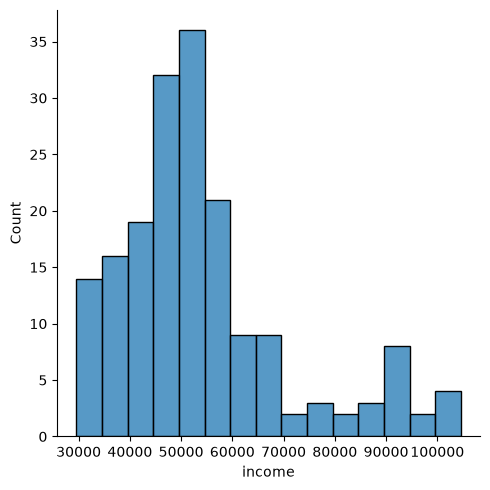

In [95]:
sns.displot(df_cat['income'])

In [96]:
bins = [0, 45000, 65000, 120000]
labels = ['low_inc', 'med_inc', 'high_inc']
df_cat['income_cat'] = pd.cut(df_cat['income'], bins=bins, labels=labels, right=True)
df_cat['income_cat'].value_counts()

income_cat
med_inc     103
low_inc      49
high_inc     28
Name: count, dtype: int64

#### `miles`

In [97]:
df_cat['miles'].min()

np.int64(21)

In [98]:
df_cat['miles'].max()

np.int64(360)

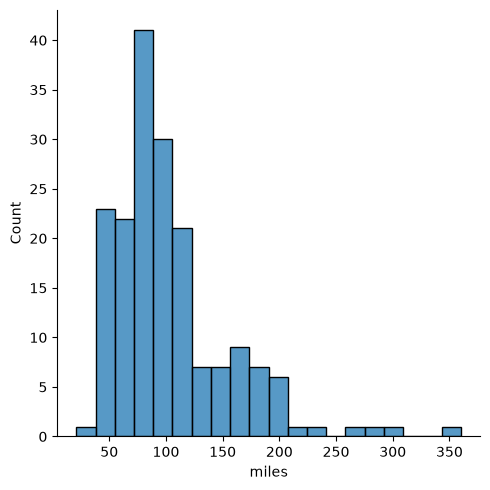

In [99]:
sns.displot(df['miles'])

In [100]:
bins = [9, 50, 120, 400]
labels = ['low_miles', 'med_miles', 'high_miles']
df_cat['miles_cat'] = pd.cut(df_cat['miles'], bins=bins, labels=labels, right=True)
df_cat['miles_cat'].value_counts()

miles_cat
med_miles     121
high_miles     42
low_miles      17
Name: count, dtype: int64

### Two-Way Contingency Tables

#### `gender` and `product`

In [101]:
pd.crosstab(df_cat['gender'], df_cat['product'], margins=True)

product,KP281,KP481,KP781,All
gender,,,,
Female,40,29,7,76
Male,40,31,33,104
All,80,60,40,180


Joint and Marginal Probabilities:

In [102]:
pd.crosstab(df_cat['gender'], df_cat['product'], margins=True, normalize='all')

product,KP281,KP481,KP781,All
gender,,,,
Female,0.222222,0.161111,0.038889,0.422222
Male,0.222222,0.172222,0.183333,0.577778
All,0.444444,0.333333,0.222222,1.000000


From above table:

Joint Probabilities:

P(Female and KP281)  = 0.22 <br>
P(Female and KP481)  = 0.16<br>
P(Female and KP781)  = 0.038

P(Male and KP281)  = 0.22<br>
P(Male and KP481)  = 0.17<br>
P(Male and KP781)  = 0.18

Marginal Probabilites:

P(Female) = 0.42<br>
P(Male) = 0.57

P(KP281) = 0.44<br>
P(KP481) = 0.33<br>
P(KP781) = 0.22

<b>Conditional Probabilities: </b>

In [103]:
pd.crosstab(df_cat['gender'], df_cat['product'], normalize='index')

product,KP281,KP481,KP781
gender,,,
Female,0.526316,0.381579,0.092105
Male,0.384615,0.298077,0.317308


From above table:

P(KP281 | Female) = 0.52 <br>
P(KP281 | Male) = 0.38

P(KP481 | Female) = 0.38 <br>
P(KP481 | Male) = 0.29

P(KP781 | Female) = 0.092 <br>
P(KP781 | Male) = 0.31

In [104]:
pd.crosstab(df_cat['gender'], df_cat['product'], normalize='columns')

product,KP281,KP481,KP781
gender,,,
Female,0.5,0.483333,0.175
Male,0.5,0.516667,0.825


From above table:

P(Female | KP281) = 0.5 <br>
P(Male | KP281) = 0.5

P(Female | KP481) = 0.48 <br>
P(Male | KP481) = 0.41

P(Female | KP781) = 0.17 <br>
P(Male | KP781) = 0.82

#### `age_cat` and `product`

In [105]:
pd.crosstab(df_cat['age_cat'], df_cat['product'], margins=True)

product,KP281,KP481,KP781,All
age_cat,,,,
low_age,34,28,17,79
med_age,40,30,19,89
high_age,6,2,4,12
All,80,60,40,180


In [106]:
pd.crosstab(df_cat['age_cat'], df_cat['product'], margins=True, normalize='all')

product,KP281,KP481,KP781,All
age_cat,,,,
low_age,0.188889,0.155556,0.094444,0.438889
med_age,0.222222,0.166667,0.105556,0.494444
high_age,0.033333,0.011111,0.022222,0.066667
All,0.444444,0.333333,0.222222,1.000000


In [107]:
pd.crosstab(df_cat['age_cat'], df_cat['product'], normalize='index')

product,KP281,KP481,KP781
age_cat,,,
low_age,0.430380,0.354430,0.215190
med_age,0.449438,0.337079,0.213483
high_age,0.500000,0.166667,0.333333


#### `education_cat` and `product`

In [108]:
pd.crosstab(df_cat['education_cat'], df_cat['product'], margins=True)

product,KP281,KP481,KP781,All
education_cat,,,,
low_edu,35,26,2,63
med_edu,43,32,15,90
high_edu,2,2,23,27
All,80,60,40,180


In [109]:
pd.crosstab(df_cat['education_cat'], df_cat['product'], margins=True, normalize='all')

product,KP281,KP481,KP781,All
education_cat,,,,
low_edu,0.194444,0.144444,0.011111,0.35
med_edu,0.238889,0.177778,0.083333,0.50
high_edu,0.011111,0.011111,0.127778,0.15
All,0.444444,0.333333,0.222222,1.00


In [110]:
pd.crosstab(df_cat['education_cat'], df_cat['product'], normalize='index')

product,KP281,KP481,KP781
education_cat,,,
low_edu,0.555556,0.412698,0.031746
med_edu,0.477778,0.355556,0.166667
high_edu,0.074074,0.074074,0.851852


#### `marital_status` and `product`

In [111]:
pd.crosstab(df_cat['marital_status'], df_cat['product'], margins=True)

product,KP281,KP481,KP781,All
marital_status,,,,
Partnered,48,36,23,107
Single,32,24,17,73
All,80,60,40,180


In [112]:
pd.crosstab(df_cat['marital_status'], df_cat['product'], margins=True, normalize='all')

product,KP281,KP481,KP781,All
marital_status,,,,
Partnered,0.266667,0.200000,0.127778,0.594444
Single,0.177778,0.133333,0.094444,0.405556
All,0.444444,0.333333,0.222222,1.000000


In [113]:
pd.crosstab(df_cat['marital_status'], df_cat['product'], normalize='index')

product,KP281,KP481,KP781
marital_status,,,
Partnered,0.448598,0.336449,0.214953
Single,0.438356,0.328767,0.232877


#### `usage_cat` and `product`

In [114]:
pd.crosstab(df_cat['usage_cat'], df_cat['product'], margins=True)

product,KP281,KP481,KP781,All
usage_cat,,,,
low_usage,19,14,0,33
med_usage,59,43,19,121
high_usage,2,3,21,26
All,80,60,40,180


In [115]:
pd.crosstab(df_cat['usage_cat'], df_cat['product'], margins=True, normalize='all')

product,KP281,KP481,KP781,All
usage_cat,,,,
low_usage,0.105556,0.077778,0.000000,0.183333
med_usage,0.327778,0.238889,0.105556,0.672222
high_usage,0.011111,0.016667,0.116667,0.144444
All,0.444444,0.333333,0.222222,1.000000


In [116]:
pd.crosstab(df_cat['usage_cat'], df_cat['product'], normalize='index')

product,KP281,KP481,KP781
usage_cat,,,
low_usage,0.575758,0.424242,0.000000
med_usage,0.487603,0.355372,0.157025
high_usage,0.076923,0.115385,0.807692


#### `fitness_cat` and `product`

In [117]:
pd.crosstab(df_cat['fitness_cat'], df_cat['product'], margins=True)

product,KP281,KP481,KP781,All
fitness_cat,,,,
low_fit,15,13,0,28
med_fit,54,39,4,97
high_fit,11,8,36,55
All,80,60,40,180


In [118]:
pd.crosstab(df_cat['fitness_cat'], df_cat['product'], margins=True, normalize='all')

product,KP281,KP481,KP781,All
fitness_cat,,,,
low_fit,0.083333,0.072222,0.000000,0.155556
med_fit,0.300000,0.216667,0.022222,0.538889
high_fit,0.061111,0.044444,0.200000,0.305556
All,0.444444,0.333333,0.222222,1.000000


In [119]:
pd.crosstab(df_cat['fitness_cat'], df_cat['product'], normalize='index')

product,KP281,KP481,KP781
fitness_cat,,,
low_fit,0.535714,0.464286,0.000000
med_fit,0.556701,0.402062,0.041237
high_fit,0.200000,0.145455,0.654545


#### `income_cat` and `product`

In [120]:
pd.crosstab(df_cat['income_cat'], df_cat['product'], margins=True)

product,KP281,KP481,KP781,All
income_cat,,,,
low_inc,34,15,0,49
med_inc,44,43,16,103
high_inc,2,2,24,28
All,80,60,40,180


In [121]:
pd.crosstab(df_cat['income_cat'], df_cat['product'], margins=True, normalize='all')

product,KP281,KP481,KP781,All
income_cat,,,,
low_inc,0.188889,0.083333,0.000000,0.272222
med_inc,0.244444,0.238889,0.088889,0.572222
high_inc,0.011111,0.011111,0.133333,0.155556
All,0.444444,0.333333,0.222222,1.000000


In [122]:
pd.crosstab(df_cat['income_cat'], df_cat['product'], normalize='index')

product,KP281,KP481,KP781
income_cat,,,
low_inc,0.693878,0.306122,0.000000
med_inc,0.427184,0.417476,0.155340
high_inc,0.071429,0.071429,0.857143


#### `miles_cat` and `product`

In [123]:
pd.crosstab(df_cat['miles_cat'], df_cat['product'], margins=True)

product,KP281,KP481,KP781,All
miles_cat,,,,
low_miles,12,5,0,17
med_miles,62,47,12,121
high_miles,6,8,28,42
All,80,60,40,180


In [124]:
pd.crosstab(df_cat['miles_cat'], df_cat['product'], margins=True, normalize='all')

product,KP281,KP481,KP781,All
miles_cat,,,,
low_miles,0.066667,0.027778,0.000000,0.094444
med_miles,0.344444,0.261111,0.066667,0.672222
high_miles,0.033333,0.044444,0.155556,0.233333
All,0.444444,0.333333,0.222222,1.000000


In [125]:
pd.crosstab(df_cat['miles_cat'], df_cat['product'], normalize='index')

product,KP281,KP481,KP781
miles_cat,,,
low_miles,0.705882,0.294118,0.000000
med_miles,0.512397,0.388430,0.099174
high_miles,0.142857,0.190476,0.666667
